<a href="https://colab.research.google.com/github/NazHub1993/Deep-Learning/blob/main/CIFAR_10_Image_Classification_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import datasets,layers,models

In [2]:
(x_train,y_train),(x_test,y_test)=datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [3]:
x_train.shape

(50000, 32, 32, 3)

In [4]:
x_test.shape

(10000, 32, 32, 3)

In [5]:
y_train.shape

(50000, 1)

In [6]:
y_test.shape

(10000, 1)

In [7]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [8]:
y_train=y_train.reshape(-1,)
y_train

array([6, 9, 9, ..., 9, 1, 1], dtype=uint8)

In [9]:
y_test=y_test.reshape(-1,)
y_test

array([3, 8, 8, ..., 5, 1, 7], dtype=uint8)

In [10]:
classes=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

#Let's plot some images in here

In [11]:
def plot_images(X,Y,index):
  plt.figure(figsize=(15,5))
  plt.imshow(X[index])
  plt.xlabel(classes[Y[index]])


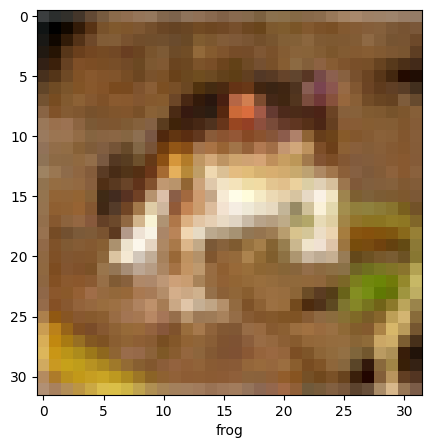

In [12]:
plot_images(x_train,y_train,0)

#Normalizing the training data

In [13]:
x_train=x_train/255
x_test= x_test/255

In [14]:
ann=models.Sequential(
    [layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000,activation='relu'),
    layers.Dense(1000,activation='relu'),
    layers.Dense(10,activation='softmax')]
)
ann.compile(optimizer='SGD',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
ann.fit(x_train,y_train,epochs=5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3521 - loss: 1.8131
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4289 - loss: 1.6231
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4553 - loss: 1.5406
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4811 - loss: 1.4786
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4958 - loss: 1.4303


In [16]:
from sklearn.metrics import confusion_matrix,classification_report
y_pred=ann.predict(x_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[1.41976932e-02, 5.32269701e-02, 1.13252804e-01, 4.16148156e-01,
        3.87186706e-02, 1.42178118e-01, 1.72568664e-01, 3.65134166e-03,
        4.01011780e-02, 5.95639832e-03],
       [6.07635565e-02, 2.42346451e-01, 5.03712567e-03, 7.95825478e-03,
        3.50331864e-03, 2.41653714e-03, 9.45944223e-04, 1.28966628e-03,
        2.76052833e-01, 3.99686366e-01],
       [2.51037329e-01, 1.05896719e-01, 5.80008049e-03, 5.85777638e-03,
        5.06460620e-03, 4.84338356e-03, 2.37133499e-04, 4.47026314e-03,
        5.28153241e-01, 8.86394605e-02],
       [2.42716819e-01, 5.30354902e-02, 1.61983296e-01, 7.64857605e-02,
        1.26650304e-01, 5.01398817e-02, 3.69594013e-03, 8.80438089e-02,
        1.63148537e-01, 3.41001451e-02],
       [4.63896152e-03, 2.84827803e-03, 1.16790034e-01, 4.08857688e-02,
        4.78436947e-01, 4.80454825e-02, 2.86558062e-01, 1.22875823e-02,
        8.65579583e-03, 8.53115052e-04]], dtype=float32)

In [17]:
y_pred_vals=[]
for element in y_pred:
  y_pred_vals.append(np.argmax(element))


In [18]:
y_pred_vals[:5]

[np.int64(3), np.int64(9), np.int64(8), np.int64(0), np.int64(4)]

In [19]:
print(classification_report(y_test,y_pred_vals))

              precision    recall  f1-score   support

           0       0.57      0.56      0.56      1000
           1       0.61      0.65      0.63      1000
           2       0.41      0.35      0.38      1000
           3       0.33      0.34      0.33      1000
           4       0.46      0.37      0.41      1000
           5       0.38      0.43      0.40      1000
           6       0.44      0.67      0.53      1000
           7       0.64      0.47      0.54      1000
           8       0.64      0.60      0.62      1000
           9       0.58      0.54      0.56      1000

    accuracy                           0.50     10000
   macro avg       0.51      0.50      0.50     10000
weighted avg       0.51      0.50      0.50     10000



In [23]:
cnn=models.Sequential(
    [

    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),


    layers.Flatten(),
    layers.Dense(3000,activation='relu'),
    layers.Dense(1000,activation='relu'),
    layers.Dense(10,activation='softmax')]
)
cnn.compile(optimizer='SGD',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
cnn.fit(x_train,y_train,epochs=50)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2946 - loss: 1.9505
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4427 - loss: 1.5558
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5130 - loss: 1.3649
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5628 - loss: 1.2429
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6002 - loss: 1.1367
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6348 - loss: 1.0445
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6662 - loss: 0.9557
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6989 - loss: 0.8697
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7269 - loss: 0.7882
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7582 - loss: 0.7017
Epoch 11/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7878 - loss: 0.6156
Epoch 12/50
1563/1563 ━━━━━━━

In [24]:
cnn.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7082 - loss: 1.9628


[1.9627548456192017, 0.7081999778747559]

In [26]:
y_pred=cnn.predict(x_test)
y_pred_vals=[]

for element in y_pred:
  y_pred_vals.append(np.argmax(element))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [28]:
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(y_test,y_pred_vals))

              precision    recall  f1-score   support

           0       0.74      0.77      0.76      1000
           1       0.82      0.80      0.81      1000
           2       0.65      0.59      0.62      1000
           3       0.54      0.54      0.54      1000
           4       0.65      0.65      0.65      1000
           5       0.62      0.61      0.61      1000
           6       0.74      0.78      0.76      1000
           7       0.75      0.76      0.76      1000
           8       0.81      0.80      0.81      1000
           9       0.76      0.78      0.77      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



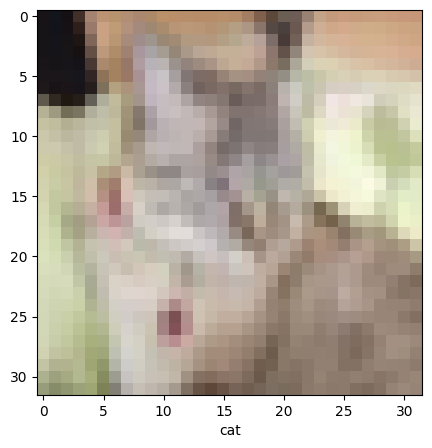

In [32]:
plot_images(x_test,y_test,6)

In [31]:
classes[y_pred_vals[8]]

'cat'